# Firasa - Exploratory Data Analysis (American Express Default Prediction Dataset)

**Dataset:** [Amex Parquet (Kaggle)](https://www.kaggle.com/datasets/odins0n/amex-parquet)

**Objective:** Explore and clean a 500K-row sample of the American Express default prediction dataset to understand feature quality, missing data patterns, and which features are most associated with customer default (`target`).

**Sampling note:** Rows in this dataset represent monthly snapshots per customer. To preserve each customer's full time series, sampling was done at the `customer_ID` level (not random rows), so no customer has a partially-cut history.

## Step 1: Import Libraries and Connect to Kaggle

We need `pandas` for data manipulation, `polars` for fast/low-memory reading of the large parquet file, and `matplotlib` / `seaborn` for visualization. The Kaggle API lets us pull the dataset directly into Colab instead of downloading it manually.

In [ ]:
!pip install -q polars seaborn

import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

pd.set_option('display.max_columns', 50)

## Step 2: Download the Dataset

We download the full dataset from Kaggle (both train and test parquet files come bundled together), but only `train_data.parquet` is used in this analysis, since it is the only file containing the `target` column.

In [ ]:
from google.colab import files
files.upload()  # upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"abr0036","key":"7fc97c30494c72d541139d805f2d47d7"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d odins0n/amex-parquet -p /content/data --unzip
!ls -la /content/data

Dataset URL: https://www.kaggle.com/datasets/odins0n/amex-parquet
License(s): CC0-1.0
100% 8.65G/8.65G [02:00<00:00, 77.4MB/s]

total 10163436
drwxr-xr-x 2 root root       4096 Sep 20 14:58 .
drwxr-xr-x 1 root root       4096 Sep 20 14:54 ..
-rw-r--r-- 1 root root 6955699257 Sep 20 14:57 test_data.parquet
-rw-r--r-- 1 root root 3451638704 Sep 20 14:58 train_data.parquet


In [ ]:
path = '/content/data/train_data.parquet'

print("Head of the original dataset:")
original_df_head = pl.scan_parquet(path).head(5).collect()
original_df_head


Head of the original dataset:


customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,D_42,D_43,D_44,B_4,D_45,B_5,R_2,D_46,D_47,D_48,D_49,B_6,B_7,B_8,D_50,D_51,B_9,R_3,D_52,P_3,B_10,D_53,S_5,B_11,S_6,D_54,R_4,…,D_114,D_115,D_116,D_117,D_118,D_119,D_120,D_121,D_122,D_123,D_124,D_125,D_126,D_127,D_128,D_129,B_41,B_42,D_130,D_131,D_132,D_133,R_28,D_134,D_135,D_136,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145,target,__index_level_0__
str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,…,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i64,i64
"""0000099d6bd597052cdcda90ffabf5…","""2017-03-09""",0.938469,0.001733,0.008724,1.006838,0.009228,0.124035,0.008771,0.004709,null,null,0.00063,0.080986,0.708906,0.1706,0.006204,0.358587,0.525351,0.255736,null,0.063902,0.059416,0.006466,0.148698,1.335856,0.008207,0.001423,0.207334,0.736463,0.096219,null,0.023381,0.002768,0.008322,1.001519,0.008298,…,1.0,0.23825,0.0,4.0,0.23212,0.236266,0.0,0.70228,0.434345,0.003057,0.686516,0.00874,1.0,1.003319,1.007819,1.00008,0.006805,null,0.002052,0.005972,null,0.004345,0.001535,null,null,null,null,null,0.002427,0.003706,0.003818,null,0.000569,0.00061,0.002674,0,0
"""0000099d6bd597052cdcda90ffabf5…","""2017-04-07""",0.936665,0.005775,0.004923,1.000653,0.006151,0.12675,0.000798,0.002714,null,null,0.002526,0.069419,0.712795,0.113239,0.006206,0.35363,0.521311,0.223329,null,0.065261,0.057744,0.001614,0.149723,1.339794,0.008373,0.001984,0.202778,0.720886,0.099804,null,0.030599,0.002749,0.002482,1.009033,0.005136,…,1.0,0.247217,0.0,4.0,0.243532,0.241885,0.0,0.707017,0.430501,0.001306,0.686414,0.000755,1.0,1.008394,1.004333,1.008344,0.004407,null,0.001034,0.004838,null,0.007495,0.004931,null,null,null,null,null,0.003954,0.003167,0.005032,null,0.009576,0.005492,0.009217,0,1
"""0000099d6bd597052cdcda90ffabf5…","""2017-05-28""",0.95418,0.091505,0.021655,1.009672,0.006815,0.123977,0.007598,0.009423,null,null,0.007605,0.068839,0.720884,0.060492,0.003259,0.33465,0.524568,0.189424,null,0.066982,0.056647,0.005126,0.151955,1.337179,0.009355,0.007426,0.206629,0.738044,0.134073,null,0.048367,0.010077,0.00053,1.009184,0.006961,…,1.0,0.239867,0.0,4.0,0.240768,0.23971,0.0,0.704843,0.434409,0.003954,0.690101,0.009617,1.0,1.009307,1.007831,1.006878,0.003221,null,0.005681,0.005497,null,0.009227,0.009123,null,null,null,null,null,0.003269,0.007329,0.000427,null,0.003429,0.006986,0.002603,0,2
"""0000099d6bd597052cdcda90ffabf5…","""2017-06-13""",0.960384,0.002455,0.013683,1.0027,0.001373,0.117169,0.000685,0.005531,null,null,0.006406,0.05563,0.723997,0.166782,0.009918,0.323271,0.530929,0.135586,null,0.08372,0.049253,0.001418,0.151219,1.339909,0.006782,0.003515,0.208214,0.741813,0.134437,null,0.030063,0.009667,0.000783,1.007455,0.008706,…,1.0,0.24091,0.0,4.0,0.2394,0.240727,0.0,0.711546,0.436903,0.005135,0.687779,0.004649,1.0,1.001671,1.00346,1.007573,0.007703,null,0.007108,0.008261,null,0.007206,0.002409,null,null,null,null,null,0.006117,0.004516,0.0032,null,0.008419,0.006527,0.0096,0,3
"""0000099d6bd597052cdcda90ffabf5…","""2017-07-16""",0.947248,0.002483,0.015193,1.000727,0.007605,0.117325,0.004653,0.009312,null,null,0.007731,0.038862,0.720619,0.14363,0.006667,0.231009,0.529305,null,null,0.0759,0.048918,0.001199,0.154026,1.341735,0.000519,0.001362,0.205468,0.691986,0.121518,null,0.054221,0.009484,0.006698,1.003738,0.003846,…,1.0,0.247939,0.0,4.0,0.244199,0.242325,0.0,0.705343,0.437433,0.002849,0.688774,0.000097,1.0,1.009886,1.005053,1.008132,0.009823,null,0.00968,0.004848,null,0.006312,0.004462,null,null,null,null,null,0.003671,0.004946,0.008889,null,0.00167,0.008126,0.009827,0,4


In [ ]:
row_count = pl.scan_parquet(path).select(pl.len()).collect().item()
column_count = len(pl.scan_parquet(path).collect_schema())
print(f'\nThe shape of original Dataset: ({row_count}, {column_count})')


The shape of original Dataset: (5531451, 192)


## Step 3: Sample 500K Rows at the Customer Level

Rather than sampling random rows (which would cut some customers' monthly records in half), we:
1. Get all unique `customer_ID`s
2. Calculate the **actual** average number of monthly records per customer (not an estimate), so we know exactly how many customers to sample to land near 500,000 rows
3. Randomly sample that many customers and pull **all** of their records

In [ ]:
path = '/content/data/train_data.parquet'

# Get all unique customer IDs
customers = (
    pl.scan_parquet(path)
    .select('customer_ID')
    .unique()
    .sort('customer_ID')  # To have same random number
    .collect()
)
print("Unique customers in full dataset:", customers.shape[0])

Unique customers in full dataset: 458913


In [ ]:
# Calculate the ACTUAL average number of monthly records per customer,
# instead of assuming a fixed number - this makes the sample size much more accurate
avg_rows_per_customer = (
    pl.scan_parquet(path)
    .group_by('customer_ID')
    .len()
    .select(pl.col('len').mean())
    .collect()
    .item()
)
print("Actual average records per customer:", round(avg_rows_per_customer, 2))

target_customers = int(500_000 // avg_rows_per_customer)

sampled_customers = customers.sample(n=target_customers, seed=42)

df_sample = (
    pl.scan_parquet(path)
    .join(sampled_customers.lazy(), on='customer_ID', how='inner')
    .collect()
)

print("Sample shape:", df_sample.shape)
print("sampled customers count:", sampled_customers.shape[0])

Actual average records per customer: 12.05
Sample shape: (501032, 192)
sampled customers count: 41482


In [ ]:
df = df_sample.to_pandas()
del df_sample, customers, sampled_customers
gc.collect()

print(df.shape)
df.head()

(501032, 192)


,customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,D_42,D_43,D_44,B_4,D_45,B_5,R_2,D_46,D_47,D_48,D_49,B_6,B_7,B_8,D_50,...,D_126,D_127,D_128,D_129,B_41,B_42,D_130,D_131,D_132,D_133,R_28,D_134,D_135,D_136,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145,target,__index_level_0__
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-03-09,0.938469,0.001733,0.008724,1.006838,0.009228,0.124035,0.008771,0.004709,NaN,NaN,0.000630,0.080986,0.708906,0.170600,0.006204,0.358587,0.525351,0.255736,NaN,0.063902,0.059416,0.006466,0.148698,...,1.0,1.003319,1.007819,1.000080,0.006805,NaN,0.002052,0.005972,NaN,0.004345,0.001535,NaN,NaN,NaN,NaN,NaN,0.002427,0.003706,0.003818,NaN,0.000569,0.000610,0.002674,0,0
1,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-04-07,0.936665,0.005775,0.004923,1.000653,0.006151,0.126750,0.000798,0.002714,NaN,NaN,0.002526,0.069419,0.712795,0.113239,0.006206,0.353630,0.521311,0.223329,NaN,0.065261,0.057744,0.001614,0.149723,...,1.0,1.008394,1.004333,1.008344,0.004407,NaN,0.001034,0.004838,NaN,0.007495,0.004931,NaN,NaN,NaN,NaN,NaN,0.003954,0.003167,0.005032,NaN,0.009576,0.005492,0.009217,0,1
2,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-05-28,0.954180,0.091505,0.021655,1.009672,0.006815,0.123977,0.007598,0.009423,NaN,NaN,0.007605,0.068839,0.720884,0.060492,0.003259,0.334650,0.524568,0.189424,NaN,0.066982,0.056647,0.005126,0.151955,...,1.0,1.009307,1.007831,1.006878,0.003221,NaN,0.005681,0.005497,NaN,0.009227,0.009123,NaN,NaN,NaN,NaN,NaN,0.003269,0.007329,0.000427,NaN,0.003429,0.006986,0.002603,0,2
3,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-06-13,0.960384,0.002455,0.013683,1.002700,0.001373,0.117169,0.000685,0.005531,NaN,NaN,0.006406,0.055630,0.723997,0.166782,0.009918,0.323271,0.530929,0.135586,NaN,0.083720,0.049253,0.001418,0.151219,...,1.0,1.001671,1.003460,1.007573,0.007703,NaN,0.007108,0.008261,NaN,0.007206,0.002409,NaN,NaN,NaN,NaN,NaN,0.006117,0.004516,0.003200,NaN,0.008419,0.006527,0.009600,0,3
4,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-07-16,0.947248,0.002483,0.015193,1.000727,0.007605,0.117325,0.004653,0.009312,NaN,NaN,0.007731,0.038862,0.720619,0.143630,0.006667,0.231009,0.529305,NaN,NaN,0.075900,0.048918,0.001199,0.154026,...,1.0,1.009886,1.005053,1.008132,0.009823,NaN,0.009680,0.004848,NaN,0.006312,0.004462,NaN,NaN,NaN,NaN,NaN,0.003671,0.004946,0.008889,NaN,0.001670,0.008126,0.009827,0,4


**Insight:** We've got around 458,913 unique customers in the full dataset. Pulled a sample of about 41,482 of them, averaging 12.05 records each, and ended up with 501,032 rows and 192 columns, right around our 500K target. Best part is we kept each customer's full monthly history intact, nothing got cut off.


## Step 4: Initial Data Overview

Before cleaning anything, we check the overall shape, column data types, and a preview of the data to understand what we're working with.

In [ ]:
print("Shape:", df.shape)
print("\nData types summary:")
print(df.dtypes.value_counts())

Shape: (501032, 192)

Data types summary:
float32    185
object       4
int64        3
Name: count, dtype: int64


In [ ]:
df.describe()

,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,D_42,D_43,D_44,B_4,D_45,B_5,R_2,D_46,D_47,D_48,D_49,B_6,B_7,B_8,D_50,D_51,B_9,...,D_126,D_127,D_128,D_129,B_41,B_42,D_130,D_131,D_132,D_133,R_28,D_134,D_135,D_136,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145,target,__index_level_0__
count,496970.000000,5.010320e+05,501032.000000,5.008580e+05,5.010320e+05,407949.000000,5.008580e+05,5.008580e+05,71369.000000,352483.000000,4.766040e+05,5.010320e+05,500858.000000,5.010320e+05,5.010320e+05,392005.000000,501032.000000,436604.000000,49151.000000,501016.000000,501032.000000,4.989300e+05,215235.000000,5.010320e+05,5.010320e+05,...,490444.000000,5.010320e+05,4.915870e+05,4.915870e+05,5.009720e+05,6205.000000,4.915870e+05,4.915870e+05,48879.000000,4.970270e+05,5.010320e+05,17962.000000,1.796200e+04,1.796200e+04,1.796200e+04,17962.000000,4.915870e+05,4.972250e+05,4.915870e+05,85532.000000,4.915870e+05,4.972100e+05,4.915870e+05,501032.000000,5.010320e+05
mean,0.656483,1.517485e-01,0.123729,6.218227e-01,7.847131e-02,0.225572,5.949023e-02,1.328417e-01,0.185389,0.154086,1.178378e-01,1.718944e-01,0.250123,8.378576e-02,4.805586e-02,0.474677,0.406168,0.380781,0.202620,0.149240,0.186362,4.532327e-01,0.172596,1.446552e-01,1.906692e-01,...,0.742350,1.099115e-01,5.852365e-01,4.378369e-01,3.288495e-02,0.098742,1.996315e-01,1.028872e-01,0.210520,4.498871e-02,5.628426e-03,0.337558,3.101550e-02,2.446973e-01,1.439228e-02,0.168861,1.789926e-01,2.707298e-02,1.645391e-01,0.389114,1.788770e-01,5.263104e-02,6.280564e-02,0.245242,2.762754e+06
std,0.243788,2.682919e-01,0.211906,4.015491e-01,2.268043e-01,0.192908,2.057122e-01,2.355792e-01,0.226592,0.211583,2.184161e-01,2.216341e-01,0.240539,3.940648e-01,2.030946e-01,0.177889,0.233404,0.326383,0.393925,0.734877,0.231629,4.971907e-01,0.496776,2.429487e-01,2.856247e-01,...,0.534136,3.067318e-01,4.928967e-01,4.955201e-01,2.395227e-01,0.212942,3.961253e-01,2.946037e-01,0.254003,1.695700e-01,2.525303e-02,0.298086,1.591445e-01,2.226856e-01,9.633613e-02,0.267451,3.792605e-01,1.469590e-01,3.482521e-01,0.236722,3.791566e-01,1.828855e-01,1.942678e-01,0.430231,1.594596e+06
min,-0.403670,5.957677e-09,-0.834858,2.024839e-07,2.600494e-09,-0.482273,5.214154e-08,6.285293e-09,-0.000226,0.000001,2.781754e-08,2.175166e-08,0.000003,9.308199e-10,4.997921e-09,-17.289343,-0.026611,-0.009615,0.000009,-0.005075,-0.572125,3.420043e-08,-1.739957,3.523041e-08,1.011233e-07,...,-1.000000,3.160816e-08,2.898620e-08,2.422876e-10,9.548740e-08,0.000011,3.793112e-09,6.428192e-09,-0.015102,3.685528e-09,5.699753e-08,-0.008685,5.010514e-07,5.736685e-07,4.829439e-07,0.000001,9.891117e-09,7.897955e-09,1.073346e-08,-0.011146,3.588682e-08,7.755673e-08,5.171373e-09,0.000000,0.000000e+00
25%,0.482273,4.512644e-03,0.008856,1.054991e-01,2.881442e-03,0.127081,2.862387e-03,5.216012e-03,0.035530,0.042643,3.826949e-03,2.719037e-02,0.054408,7.278472e-03,2.618412e-03,0.424874,0.232554,0.080216,0.062711,0.020468,0.028086,4.524134e-03,0.064474,3.631665e-03,5.788041e-03,...,1.000000,2.805809e-03,5.969792e-03,4.420270e-03,2.555324e-03,0.007499,3.097968e-03,2.765392e-03,0.071749,2.711270e-03,2.504203e-03,0.116489,2.595424e-03,9.008409e-03,2.575039e-03,0.003489,3.029849e-03,2.549434e-03,3.020882e-03,0.194920,3.038325e-03,2.751615e-03,3.036212e-03,0.000000,1.383383e+06
50%,0.694359,9.029535e-03,0.031343,8.143651e-01,5.769513e-03,0.163872,5.741981e-03,9.773226e-03,0.120399,0.087965,7.674120e-03,8.151598e-02,0.179152,1.535691e-02,5.238870e-03,0.459467,0.382982,0.283776,0.132302,0.084778,0.074826,9.057648e-03,0.109095,7.265502e-03,2.646592e-02,...,1.000000,5.592708e-03,1.000444e+00,8.815886e-03,5.102645e-03,0.023427,6.207551e-03,5.559084e-03,0.156665,5.433937e-03,4.995932e-03,0.231709,5.156367e-03,2.538255e-01,5.111606e-03,0.007071,6.046434e-03,5.105382e-03,6.044328e-03,0.380108,6.045979e-03,5.504265e-03,6.069127e-03,0.000000,2.758342e+06
75%,0.863785,2.354973e-01,0.124368,1.002407e+00,8.640520e-03,0.257811,8.606657e-03,1.555762e-01,0.248738,0.183019,1.319797e-01,2.386296e-01,0.370

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501032 entries, 0 to 501031
Columns: 192 entries, customer_ID to __index_level_0__
dtypes: float32(185), int64(3), object(4)
memory usage: 380.3+ MB


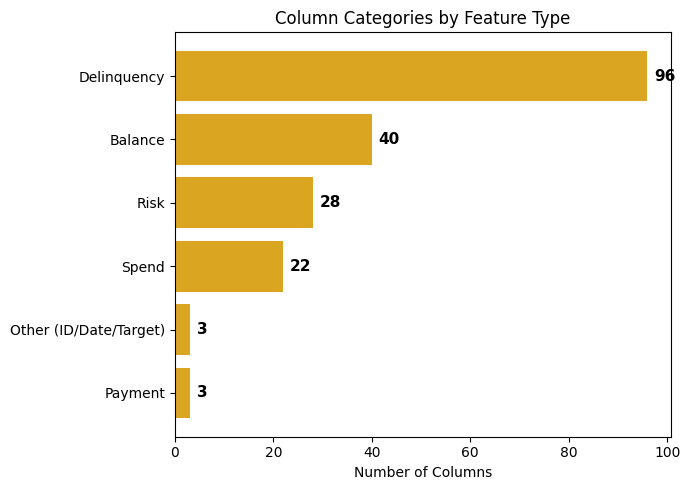

In [ ]:
prefix_map = {'D_': 'Delinquency', 'S_': 'Spend', 'P_': 'Payment',
              'B_': 'Balance', 'R_': 'Risk'}

def get_category(col):
    for prefix, name in prefix_map.items():
        if col.startswith(prefix):
            return name
    return 'Other (ID/Date/Target)'

cat_counts = df.columns.to_series().apply(get_category).value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(cat_counts.index, cat_counts.values, color='#DAA520')
ax.set_xlabel('Number of Columns')
ax.set_title('Column Categories by Feature Type')
ax.invert_yaxis()  # largest category on top

for bar in bars:
    width = bar.get_width()
    ax.annotate(f'{int(width)}', xy=(width, bar.get_y() + bar.get_height()/2),
                xytext=(5, 0), textcoords='offset points', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:** We've got 192 columns total, mostly numeric (float64), split across feature categories. Delinquency is by far the biggest group with 96 columns, basically half the dataset. Then Balance with 40, Risk with 28, and Spend with 22. Payment and the "Other" group (ID, date, target) are tiny, just 3 columns each.
Overall the data leans heavily on delinquency signals, which makes sense if the target's about predicting default or payment behavior.


## Step 4.1: Check for Disguised Missing Values (Text Placeholders)

`.isnull()` only catches real `NaN`/`None`. It won't catch values that *look* like valid data but actually mean missing things like the string `"N/A"` or `"null"` sitting inside a text column. I check this now, before Step 5's missing-value analysis, so that step's percentages aren't silently wrong. This only applies to the text columns (`customer_ID`, `S_2`, `D_63`,`D_64`) the numeric columns are already `float32` and can't hold text.

In [ ]:
# Common placeholder strings that LOOK like valid data but actually mean "missing"
suspicious_values = ['null', 'NULL', 'Null', 'N/A', 'n/a', 'NA', 'na',
                      'none', 'None', 'NONE', '', ' ', '-', '?',
                      'nan', 'NaN', '0', 'unknown', 'Unknown']

object_cols = df.select_dtypes(include='object').columns.tolist()
print("Text columns to check:", object_cols)

for col in object_cols:
    found = df[col].astype(str).str.strip().isin(suspicious_values)
    count = found.sum()
    if count > 0:
        print(f"{col}: found {count} suspicious placeholder values -> {df[col][found].unique()[:10]}")
    else:
        print(f"{col}: clean, no suspicious placeholders found")

Text columns to check: ['customer_ID', 'S_2', 'D_63', 'D_64']
customer_ID: clean, no suspicious placeholders found
S_2: clean, no suspicious placeholders found
D_63: clean, no suspicious placeholders found
D_64: found 19751 suspicious placeholder values -> [None]


In [ ]:
print(df['D_63'].unique())
print(df['D_64'].unique())

['CR' 'CO' 'CL' 'XM' 'XL' 'XZ']
['O' 'U' None 'R' '-1']


**Insight:** `customer_ID`, `S_2`, and `D_63` came back clean, no disguised text placeholders. `D_64` flagged 19,751 values as `"None"`, but that's not a new problem: `.astype(str)` turns real `None`/`NaN` into the text `"None"`, so this is the same genuine missing data `.isnull()` already tracks, not something hidden. What *is* new: printing `D_64`'s unique values directly showed a
`'-1'` entry alongside the real categories (`O`, `U`, `R`), a value our placeholder list didn't even think to check for. That needs a closer look before we treat `D_64` as clean.


## Step 4.2: Quantify D_64's `'-1'` Value

In [ ]:
print("D_64 value counts (including '-1' and None):")
print(df['D_64'].value_counts(dropna=False))

D_64 value counts (including '-1' and None):
D_64
O       263527
U       138383
R        75997
None     19751
-1        3374
Name: count, dtype: int64


**Insight:** `'-1'` shows up in only 3,374 rows (0.67%), tiny compared to the real categories (`O` 52.6%, `U` 27.6%, `R` 15.2%). That size and shape is exactly what a sentinel/placeholder value looks like, not a genuine fourth category, so we're treating it as a disguised missing value rather than real data.


## Step 4.3: Fold `'-1'` Into Missing

In [ ]:
df['D_64'] = df['D_64'].replace('-1', np.nan)

print(df['D_64'].value_counts(dropna=False))

D_64
O       263527
U       138383
R        75997
None     19751
NaN       3374
Name: count, dtype: int64


**Insight:** After the replace, `'-1'` is gone and `D_64`'s missing count rose from 19,751 to 23,125, exactly the 3,374 rows we reclassified. The values now show up split across two labels (`None` and `NaN`) because of how the original nulls vs. the newly-converted ones are stored internally, but `.isnull()`/`ffill`/`bfill` treat both identically, so Step 13's imputation isn't
affected.


## Step 5: Missing Values Analysis

We calculate the count and percentage of missing values per column, sorted from worst to best, to identify which columns are unusable.

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

print(missing_summary[missing_summary['missing_count'] > 0])

       missing_count  missing_pct
D_87          500614        99.92
D_88          500498        99.89
D_108         498349        99.46
D_110         498234        99.44
D_111         498234        99.44
...              ...          ...
R_20               8         0.00
R_12               8         0.00
R_14               1         0.00
B_40               8         0.00
B_37               8         0.00

[122 rows x 2 columns]


In [ ]:
high_missing = missing_summary[missing_summary['missing_pct'] > 50]
print(f"Columns with more than 50% missing values: {len(high_missing)}")
print(high_missing.index.tolist())

Columns with more than 50% missing values: 30
['D_87', 'D_88', 'D_108', 'D_110', 'D_111', 'B_39', 'D_73', 'B_42', 'D_135', 'D_138', 'D_137', 'D_136', 'D_134', 'R_9', 'B_29', 'D_106', 'D_132', 'D_49', 'R_26', 'D_76', 'D_66', 'D_42', 'D_142', 'D_53', 'D_82', 'D_50', 'B_17', 'D_105', 'D_56', 'S_9']


**Insight:** 30 out of 192 columns have more than 50% missing data, some as high as 99.9% like D_87 and D_88.
These columns barely carry any usable info, so dropping them makes more sense than trying to fill them in.


## Step 6: Drop Columns with >50% Missing Data

Columns that are almost entirely empty add noise rather than signal. We drop them to keep the dataset focused on features with real information.

In [ ]:
columns_to_drop = high_missing.index.tolist()

# '__index_level_0__' is a leftover pandas row-index that leaked in from the parquet
# file. It has 0% missing data, so the >50%-missing filter never catches it. It must
# be dropped explicitly, or it gets fed into the model as a fake numeric feature.
if '__index_level_0__' in df.columns:
    columns_to_drop.append('__index_level_0__')

df_clean = df.drop(columns=columns_to_drop)

print("Shape before drop:", df.shape)
print("Shape after drop:", df_clean.shape)
print("Dropped columns include index artifact:", '__index_level_0__' in columns_to_drop)

Shape before drop: (501032, 192)
Shape after drop: (501032, 161)
Dropped columns include index artifact: True


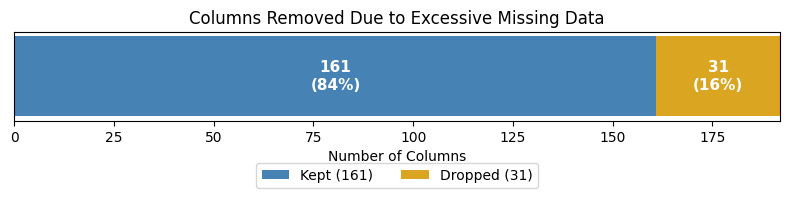

In [ ]:
kept = df_clean.shape[1]
dropped = df.shape[1] - df_clean.shape[1]
total = kept + dropped

fig, ax = plt.subplots(figsize=(8, 2.5))

ax.barh(['Columns'], [kept], color='steelblue', label=f'Kept ({kept})')
ax.barh(['Columns'], [dropped], left=[kept], color='#DAA520', label=f'Dropped ({dropped})')

ax.text(kept/2, 0, f'{kept}\n({kept/total*100:.0f}%)', ha='center', va='center',
        color='white', fontweight='bold', fontsize=11)
ax.text(kept + dropped/2, 0, f'{dropped}\n({dropped/total*100:.0f}%)', ha='center', va='center',
        color='white', fontweight='bold', fontsize=11)

ax.set_xlim(0, total)
ax.set_xlabel('Number of Columns')
ax.set_title('Columns Removed Due to Excessive Missing Data')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.4), ncol=2)
ax.set_yticks([])
plt.tight_layout()
plt.show()

**Insight:** We dropped the 30 near-empty columns plus a leftover pandas index column that got carried over as noise with no real analytical value. That took the dataset from 192 columns down to 161 without losing a single row, still 501,032 rows intact. So the data's leaner now and cleaner for modeling without sacrificing any customer records.


## Step 7: Duplicate Records Check

We check for two things: fully duplicated rows, and duplicate (customer, month) pairs, which should never occur since each customer should have one record per month.

In [ ]:
duplicates = df_clean.duplicated().sum()
print("Fully duplicated rows:", duplicates)

dup_customer_month = df_clean.duplicated(subset=['customer_ID', 'S_2']).sum()
print("Duplicate (customer_ID, S_2) pairs:", dup_customer_month)

Fully duplicated rows: 0
Duplicate (customer_ID, S_2) pairs: 0


**Insight:** Zero duplicates found in both checks. Each customer has exactly one record per month with no duplicate rows.


## Step 8: Fix the Date Column

`S_2` (the statement date) is stored as a plain text string, not a real date. We convert it to `datetime` so we can extract year/month and do time-based analysis later.

In [ ]:
df_clean['S_2'] = pd.to_datetime(df_clean['S_2'])

df_clean['year'] = df_clean['S_2'].dt.year
df_clean['month'] = df_clean['S_2'].dt.month

print(df_clean['S_2'].dtype)
df_clean[['S_2', 'year', 'month']].head()

datetime64[ns]


,S_2,year,month
0,2017-03-09,2017,3
1,2017-04-07,2017,4
2,2017-05-28,2017,5
3,2017-06-13,2017,6
4,2017-07-16,2017,7


**Insight:** We converted S_2 into a proper datetime type, and pulled out year and month as separate columns. That'll make it easier down the line to check for any seasonal or time-based patterns.


## Step 9: Target Distribution

`target` is the variable we ultimately care about: 1 = customer defaulted, 0 = customer did not. We check the balance between the two classes.

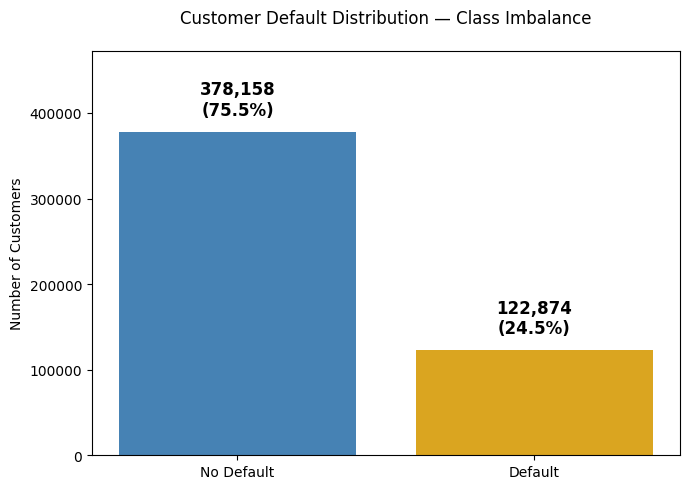

In [ ]:
counts = df_clean['target'].value_counts().sort_index()
labels = ['No Default', 'Default']
pcts = (counts / counts.sum() * 100)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, counts.values, color=['steelblue', '#DAA520'])

for bar, pct, count in zip(bars, pcts, counts):
    ax.annotate(f'{count:,}\n({pct:.1f}%)', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 12), textcoords='offset points', ha='center', fontsize=12, fontweight='bold')

ax.set_ylim(0, counts.max() * 1.25)  # extra headroom above bars
ax.set_ylabel('Number of Customers')
ax.set_title('Customer Default Distribution: Class Imbalance', pad=20)
plt.tight_layout()
plt.show()

**Insight:** 75.5% no default vs. 24.5% default, a clear imbalance, and a naive model could hit about 75% accuracy just by always guessing no default. That number would be misleading, not real performance.


## Step 10: Correlation with Target

We compute how strongly each numeric feature correlates with `target`, to identify which features carry the most signal for predicting default.

In [ ]:
numeric_cols = df_clean.select_dtypes(include='number').columns
correlations = df_clean[numeric_cols].corr()['target'].sort_values(ascending=False)

print("Top 10 positive correlations:")
print(correlations.head(11))
print("\nTop 10 negative correlations:")
print(correlations.tail(10))

Top 10 positive correlations:
target    1.000000
D_48      0.551123
D_61      0.499481
B_9       0.479234
D_44      0.472280
D_55      0.460101
D_75      0.456231
D_58      0.450565
B_7       0.433970
B_3       0.429105
B_23      0.425988
Name: target, dtype: float64

Top 10 negative correlations:
S_25   -0.248904
D_45   -0.268446
R_27   -0.268983
D_47   -0.273205
D_77   -0.332526
D_62   -0.349060
B_33   -0.449702
B_2    -0.482083
B_18   -0.485227
P_2    -0.607819
Name: target, dtype: float64


**Insight:** D_48 has the strongest positive link to the target at around 0.55, followed by D_61 and B_9, so higher values on these tend to mean higher default risk.
On the flip side, P_2 has the strongest negative link, around -0.61, meaning higher values there tend to mean lower default risk. B_18 and B_2 follow behind it.
Overall, the Delinquency (D_) and Balance (B_) columns are driving most of the relationship with the target, in both directions.


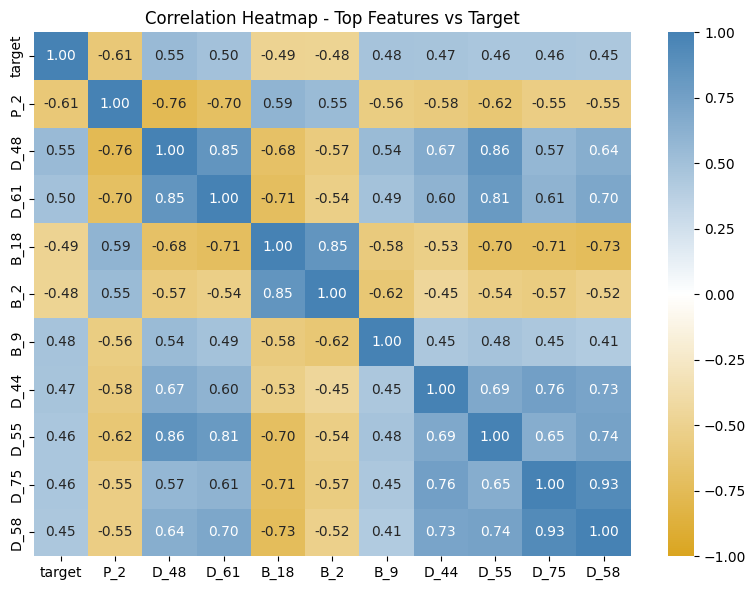

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

top_corr_cols = correlations.abs().sort_values(ascending=False).head(11).index.tolist()

custom_cmap = LinearSegmentedColormap.from_list('custom_diverging', ['#DAA520', 'white', 'steelblue'])

plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[top_corr_cols].corr(), annot=True, cmap=custom_cmap, fmt='.2f',
            center=0, vmin=-1, vmax=1)
plt.title('Correlation Heatmap - Top Features vs Target')
plt.tight_layout()
plt.show()

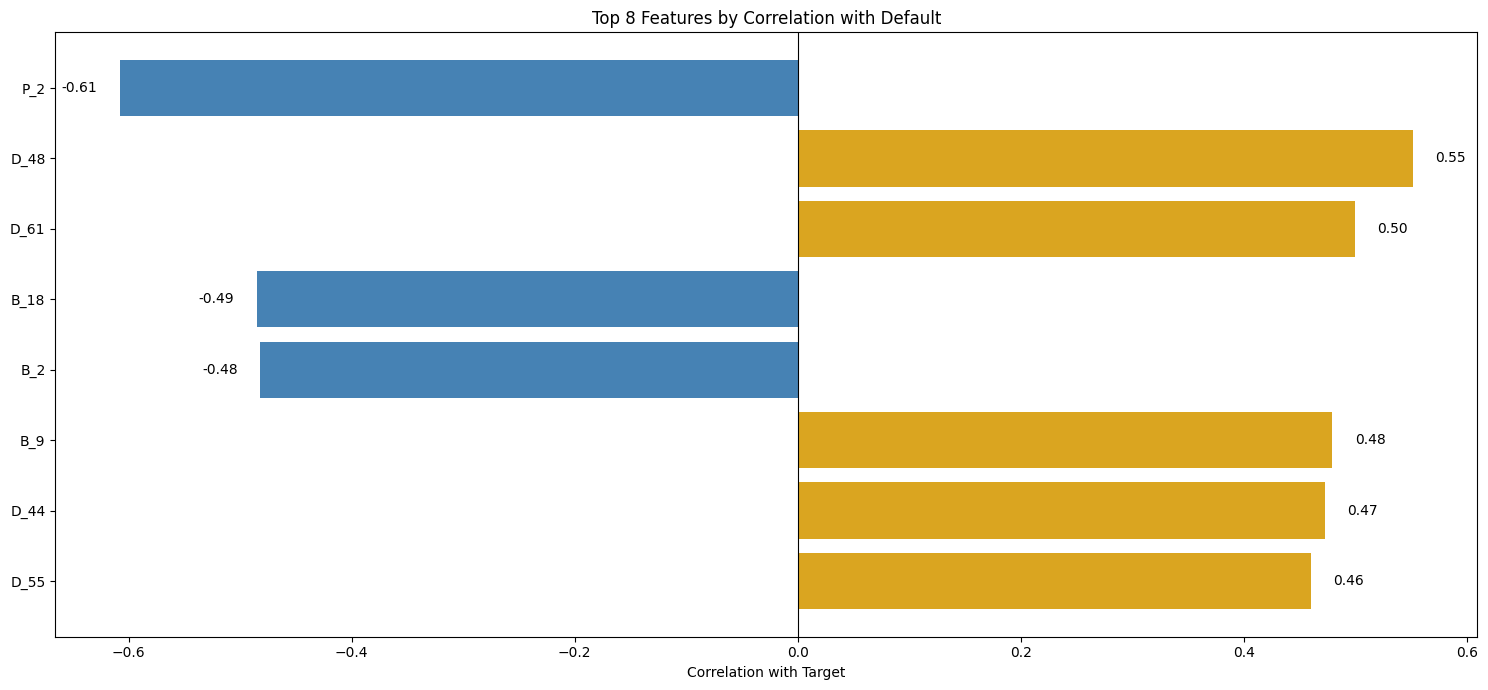

In [ ]:
top_n = 8
top_corr = correlations.drop('target').reindex(
    correlations.drop('target').abs().sort_values(ascending=False).head(top_n).index
)
colors = ['#DAA520' if v > 0 else '#4682B4' for v in top_corr.values]

fig, ax = plt.subplots(figsize=(15, 7))
ax.barh(top_corr.index, top_corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with Target')
ax.set_title(f'Top {top_n} Features by Correlation with Default')
ax.invert_yaxis()

for i, v in enumerate(top_corr.values):
    ax.text(v + (0.02 if v > 0 else -0.02), i, f'{v:.2f}',
            va='center', ha='left' if v > 0 else 'right', fontsize=10)

plt.tight_layout()
plt.show()

**Insight:** Beyond individual correlation with `target`, some features are highly correlated with each other. This is multicollinearity, these features likely carry overlapping information, which is worth remembering if these features are later used together in a predictive model.


### Step 10.1: Quantify Multicollinearity (VIF & High-Correlation Pairs)

The insight above says some features are correlated with each other, but "some" isn't
something we can act on. Two concrete checks: (1) every pair of numeric features with
|correlation| > 0.9, across the whole feature set, and (2) VIF (Variance Inflation
Factor) on the top features correlated with `target`, the interpretable subset a
Logistic Regression coefficient story would actually lean on. Both are descriptive here
(nothing gets dropped), computed on the full `df_clean` like the rest of Step 10, since
this documents the raw data's structure rather than fitting any transform.

In [ ]:
feature_cols_numeric = [c for c in numeric_cols if c not in ['target', 'year', 'month']]
corr_matrix = df_clean[feature_cols_numeric].corr().abs()

# Upper triangle only, so each pair is counted once and self-correlation is excluded
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'abs_corr'})
    .sort_values('abs_corr', ascending=False)
)
high_corr_pairs = high_corr_pairs[high_corr_pairs['abs_corr'] > 0.9]

print(f"{len(high_corr_pairs)} feature pairs have |correlation| > 0.9")
high_corr_pairs.head(20)

17 feature pairs have |correlation| > 0.9


,feature_1,feature_2,abs_corr
5896,D_62,D_77,0.999779
11349,D_103,D_104,0.999753
12077,D_139,D_143,0.999531
12076,D_139,D_141,0.998169
12084,D_141,D_143,0.997735
333,B_1,B_11,0.995771
2679,B_7,B_23,0.995217
11837,D_118,D_119,0.994641
427,B_1,B_37,0.991617
7812,D_74,D_75,0.987849


In [ ]:
!pip install -q statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_features = [c for c in top_corr_cols if c != 'target']  # top_corr_cols from Step 10's heatmap
vif_data = df_clean[vif_features].dropna()

vif_df = pd.DataFrame({
    'feature': vif_features,
    'VIF': [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_features))]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print(f"VIF computed on {len(vif_data)} complete rows (no missing among these {len(vif_features)} features).")
print("Rule of thumb: VIF > 5 = moderate concern, VIF > 10 = severe multicollinearity.")
vif_df

VIF computed on 425979 complete rows (no missing among these 10 features).
Rule of thumb: VIF > 5 = moderate concern, VIF > 10 = severe multicollinearity.


,feature,VIF
0,D_58,9.799398
1,D_75,9.097333
2,B_18,7.214964
3,D_48,6.975802
4,D_55,5.625144
5,D_61,4.868052
6,B_2,4.570335
7,D_44,3.208217
8,P_2,2.822582
9,B_9,1.910882


**Note:** these two tables are descriptive documentation, not a filtering step,
nothing gets dropped here. Run the cells above and check: which pairs cross the 0.9
threshold, and which features land above VIF 5-10. Record that in the feature
dictionary's notes if you later decide to drop or combine any of them for the Logistic
Regression pipeline specifically (tree models are not sensitive to this).

## Step 11: Distribution of Top Features by Target

We visually compare how the top 4 correlated features are distributed for defaulters vs. non-defaulters, to confirm the correlation numbers make sense visually.

In [ ]:
top_features = correlations.drop('target').abs().sort_values(ascending=False).head(4).index.tolist()
print("Top 4 features by |correlation| with target:", top_features)


Top 4 features by |correlation| with target: ['P_2', 'D_48', 'D_61', 'B_18']


**Insight:** P_2, D_48, and D_61 clearly separate the two classes by median: it shifts noticeably between defaulters and non-defaulters. B_18 shows a clear median gap too, but it's a bit less consistent than the others. P_2 and B_18 also show more outliers on the "no default" side.


## Step 11.a: Deep Dive into Top Numerical Features (Boxplots & KDE Distributions)
To better understand how our top predictors behave, we visualize them using two complementary views:
1. **Boxplots (Top Row):** Highlights the median, spread, and specifically the presence of **extreme outliers** (which justifies our Capping/Winsorization strategy later in Step 15).
2. **KDE Density Plots (Bottom Row):** Replaces noisy histograms with smooth probability distributions, showing clear separation patterns between customers who defaulted (`target = 1`) and those who did not (`target = 0`).

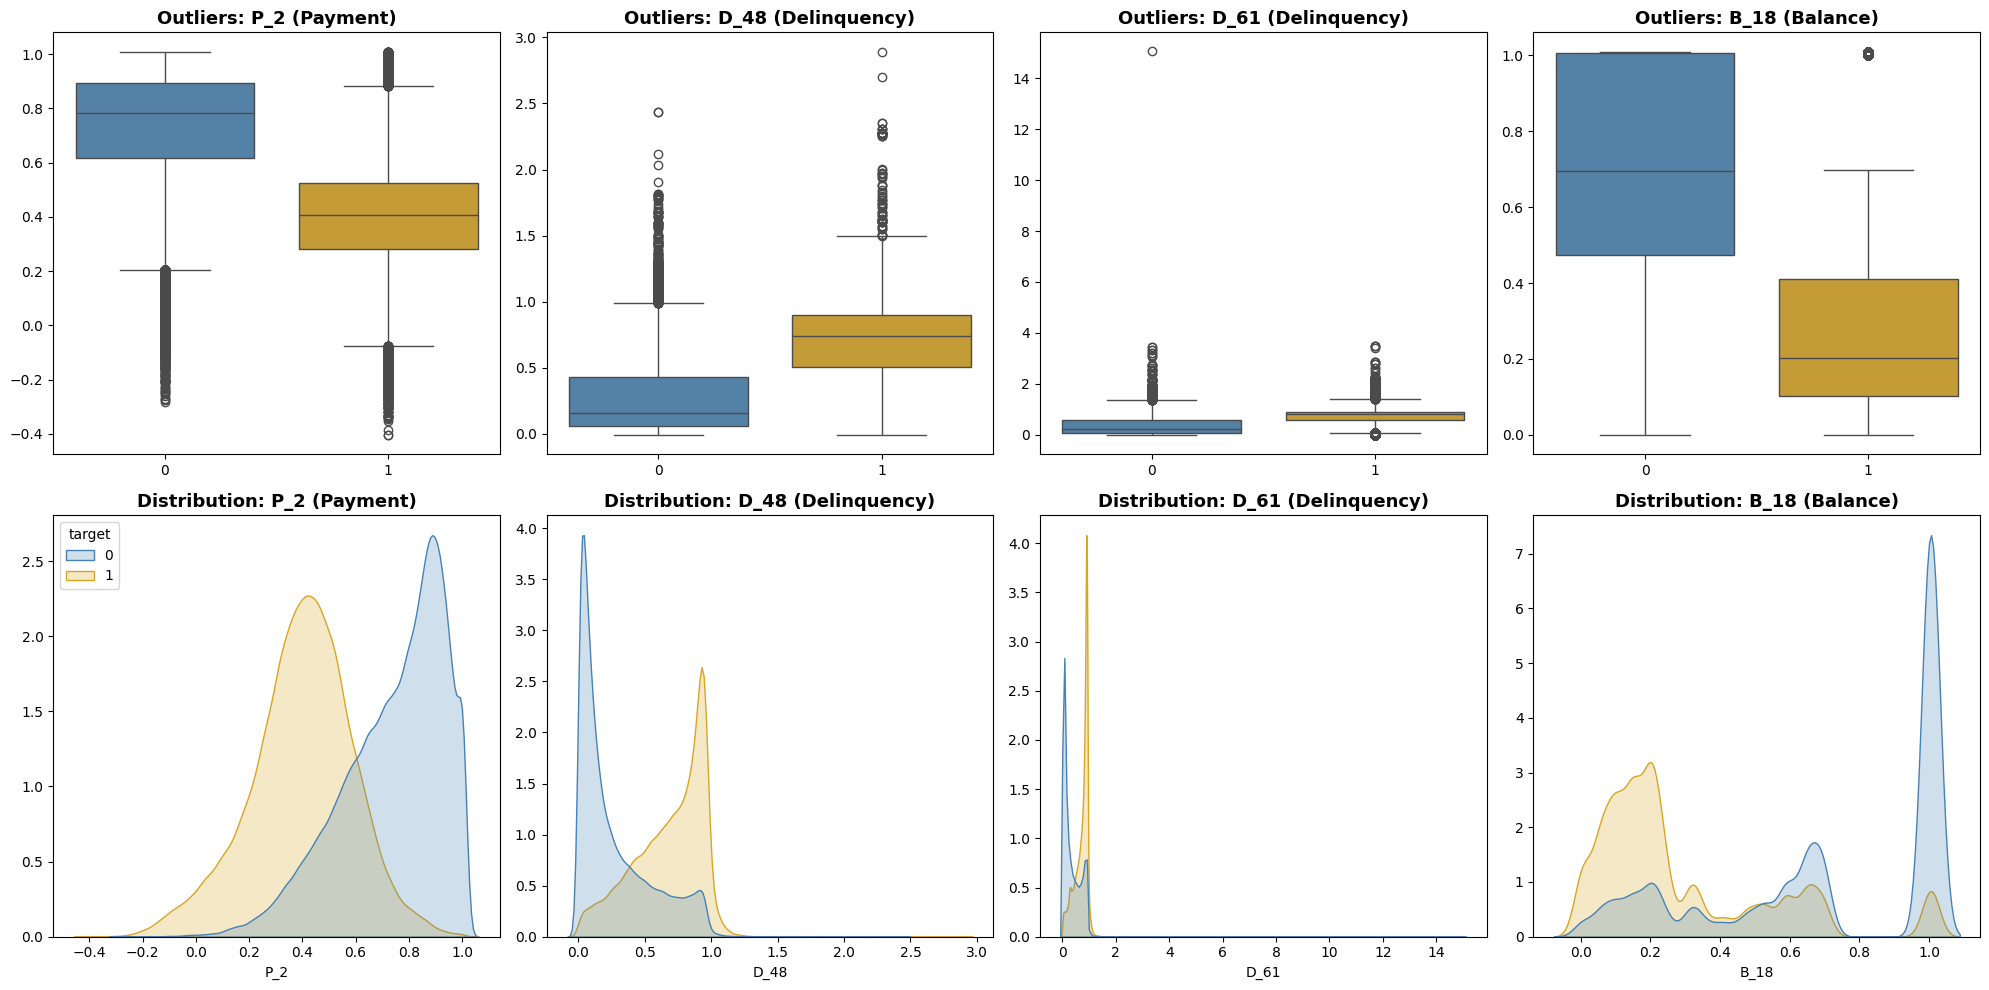

In [ ]:
top_features = correlations.drop('target').abs().sort_values(ascending=False).head(4).index.tolist()

feature_meaning = {
    'P': 'Payment',
    'D': 'Delinquency',
    'B': 'Balance',
    'S': 'Spend',
    'R': 'Risk'
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, col in enumerate(top_features):
    prefix = col[0]
    category_name = feature_meaning.get(prefix, 'Feature')

    display_name = f"{col} ({category_name})"

    sns.boxplot(y=df_clean[col], x=df_clean['target'], hue=df_clean['target'], palette=['steelblue', '#DAA520'], ax=axes[0, i], legend=False)
    axes[0, i].set_title(f'Outliers: {display_name}', fontsize=13, fontweight='bold')
    axes[0, i].set_xlabel('')
    axes[0, i].set_ylabel('')

    sns.kdeplot(data=df_clean, x=col, hue='target', fill=True, palette=['steelblue', '#DAA520'], common_norm=False, ax=axes[1, i], legend=(i==0))
    axes[1, i].set_title(f'Distribution: {display_name}', fontsize=13, fontweight='bold')
    axes[1, i].set_ylabel('')

plt.tight_layout()
plt.show()

**Insight:** P_2 shows the clearest separation between the two groups: non-defaulters cluster toward higher values (0.8 to 1.0), defaulters skew lower and wider, confirming it as the strongest single predictor of default risk. D_48 shows non-defaulters piling up near 0, while a distinct share of defaulters spike around 0.9 to 1.0. D_61 is heavily right-skewed with extreme outliers stretching the axis out well beyond 10, compressing most values near 0. B_18, by contrast, stays within a 0-1 range with a clear median gap between the two classes (higher for non-defaulters) and only a single outlier, a much milder shape than D_61's, which makes sense since B_18 replaced B_9 in this sample's top-4 ranking.


## Step 12: Categorical Features Analysis vs. Default Rate
While numerical features drive most of the signal, Amex also includes categorical/text features (`D_63` and `D_64`).
- **Customer Counts (Left):** Shows the volume distribution across different categories.
- **Default Probability (Right):** Highlights how the risk rate fluctuates significantly across categories, proving that these features hold vital predictive power once properly encoded.

/tmp/ipykernel_1596/2927440720.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=default_rate, x=col, y='target', palette='YlOrBr', ax=axes[i, 1])
/tmp/ipykernel_1596/2927440720.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=default_rate, x=col, y='target', palette='YlOrBr', ax=axes[i, 1])


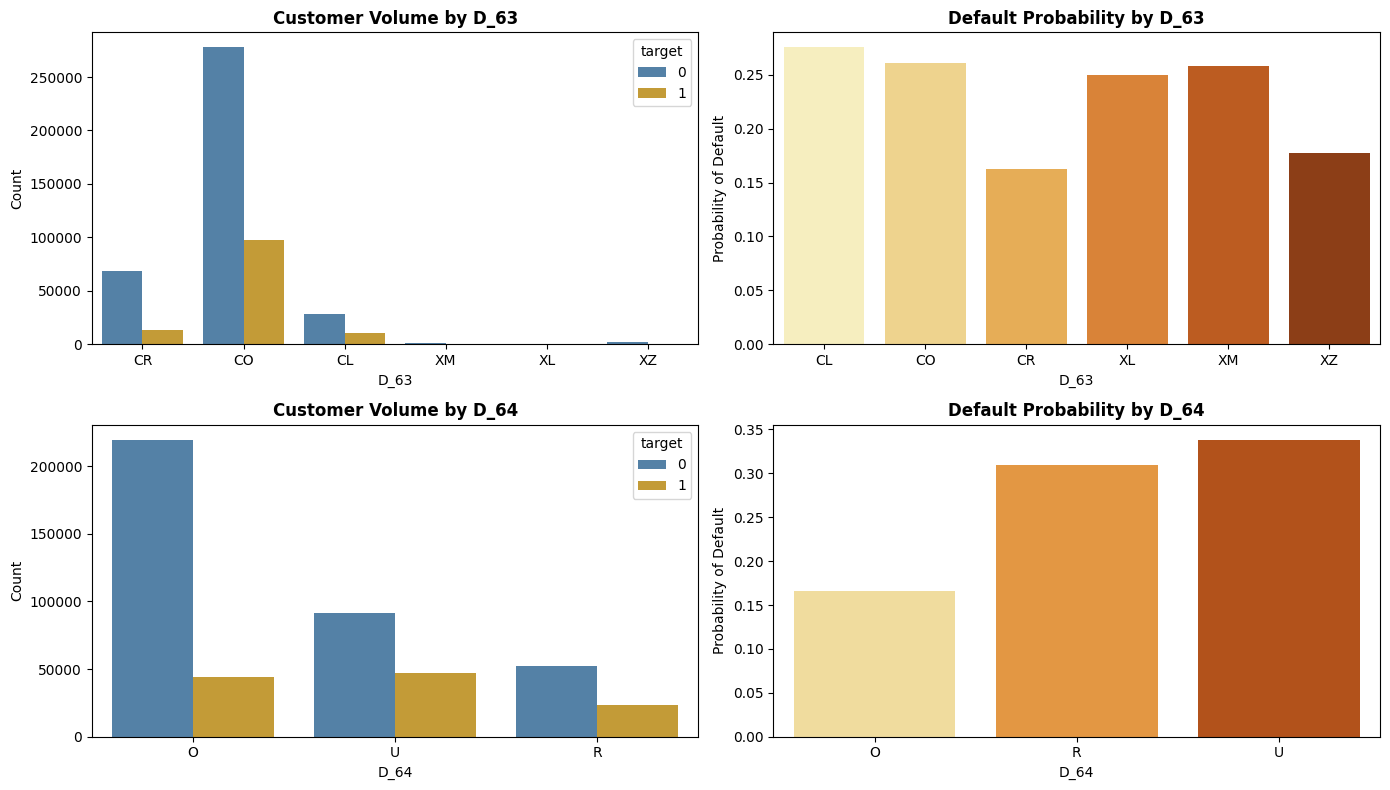

In [ ]:
cat_cols = ['D_63', 'D_64']
fig, axes = plt.subplots(len(cat_cols), 2, figsize=(14, 8))

for i, col in enumerate(cat_cols):
    if col in df_clean.columns:

        sns.countplot(data=df_clean, x=col, hue='target', palette=['steelblue', '#DAA520'], ax=axes[i, 0])
        axes[i, 0].set_title(f'Customer Volume by {col}', fontweight='bold')
        axes[i, 0].set_ylabel('Count')

        default_rate = df_clean.groupby(col)['target'].mean().reset_index()

        sns.barplot(data=default_rate, x=col, y='target', palette='YlOrBr', ax=axes[i, 1])
        axes[i, 1].set_title(f'Default Probability by {col}', fontweight='bold')
        axes[i, 1].set_ylabel('Probability of Default')

plt.tight_layout()
plt.show()

**Insight:** Both categorical features show meaningful default-rate differences across categories, confirming they carry real predictive signal. For D_63, CO dominates customer volume, and CL/CO show the highest default probability (0.25 to 0.27), while CR sits much lower (0.15) despite having a reasonable sample size. XM, XL, and XZ have very small sample sizes, so their default-rate estimates (ranging 0.15 to 0.23) are less statistically reliable. For D_64, the signal is much starker: O is the most common category with the lowest default rate (0.15), while U and R, despite smaller volumes, show roughly double the default probability (0.30 to 0.32), making D_64 a strong and reliable risk signal once encoded.


## Step 13: Sort Chronologically, Then Fill Gaps Using Each Customer's Own History

The per-customer forward/backward fill below only works correctly if each customer's
rows are in chronological order first. We sort by (`customer_ID`, `S_2`) *before* doing
any `ffill()`/`bfill()`.

This step only uses each row's own customer's history, so it does not leak information
between customers and is safe to do before the train/test split. The **global**
median/mode fallback (for customers with a value missing in *every* month) is
intentionally done later, *after* the split, using train-only statistics, see Step 14.


In [ ]:
# Sort before any ffill/bfill so "forward" and "backward" actually mean chronologically
# forward/backward per customer.
df_clean = df_clean.sort_values(['customer_ID', 'S_2']).reset_index(drop=True)

cols_with_missing = df_clean.columns[df_clean.isnull().any()].tolist()
cols_with_missing = [c for c in cols_with_missing if c not in ['target', 'customer_ID', 'S_2']]

numeric_cols_missing = df_clean[cols_with_missing].select_dtypes(include='number').columns.tolist()
categorical_cols_missing = df_clean[cols_with_missing].select_dtypes(exclude='number').columns.tolist()

print("Numeric columns with missing values:", len(numeric_cols_missing))
print("Categorical columns with missing values:", len(categorical_cols_missing), categorical_cols_missing)

Numeric columns with missing values: 91
Categorical columns with missing values: 1 ['D_64']


### Step 13a: Capture Missing-Indicator Flags & Statement Count (Before Filling)

Two features engineered from the data's *shape*, not its values: both have to be
computed here, before the fill below overwrites the evidence.
1. **`{col}_was_missing`**: for AMEX-style credit data, a customer skipping a monthly
   value is often itself a risk signal, not just noise to impute away. Once we fill it,
   that signal disappears unless we flag it first.
2. **`n_statements`**: the dataset averages ~12.05 records per customer, but that is an
   average, not a constant: customers who defaulted early or joined late may have fewer
   months of history, which can itself carry signal.

Both are computed from each row's own customer group, same as the fill below, so this
doesn't introduce any train/test leakage.


In [ ]:
missing_flag_cols = []
for col in cols_with_missing:
    flag_col = f'{col}_was_missing'
    df_clean[flag_col] = df_clean[col].isnull().astype(int)
    missing_flag_cols.append(flag_col)

print(f"Created {len(missing_flag_cols)} missing-indicator flag columns.")

df_clean['n_statements'] = df_clean.groupby('customer_ID')['customer_ID'].transform('size')

print("\nn_statements distribution:")
print(df_clean['n_statements'].describe())

print("\nDefault rate by n_statements (run and inspect: fewer statements may skew toward one class):")
print(df_clean.groupby('n_statements')['target'].mean().sort_index())

Created 92 missing-indicator flag columns.

n_statements distribution:
count    501032.000000
mean         12.625361
std           1.470521
min           1.000000
25%          13.000000
50%          13.000000
75%          13.000000
max          13.000000
Name: n_statements, dtype: float64

Default rate by n_statements (run and inspect -- fewer statements may skew toward one class):
n_statements
1     0.327231
2     0.294559
3     0.338266
4     0.429245
5     0.387387
6     0.342799
7     0.431151
8     0.447788
9     0.448217
10    0.466312
11    0.411874
12    0.360165
13    0.229255
Name: target, dtype: float64


**Note:** run the cells above and check the printed default-rate-by-`n_statements`
table for your own sample: if customers with fewer statements show a notably
different default rate, that confirms `n_statements` is worth keeping as a feature
(it flows into `train_df`/`test_df` automatically from here on, and gets aggregated
in Step 19 like any other column).


In [ ]:
# Per-customer forward/backward fill only. No dataset-wide fallback here: that would
# use test-set values to fill train rows (and vice versa). The fallback for customers
# with a value missing across their entire history happens in Step 14, after the
# train/test split, using train-only statistics.
if numeric_cols_missing:
    df_clean[numeric_cols_missing] = (
        df_clean.groupby('customer_ID')[numeric_cols_missing].ffill().bfill()
    )

if categorical_cols_missing:
    df_clean[categorical_cols_missing] = (
        df_clean.groupby('customer_ID')[categorical_cols_missing].ffill().bfill()
    )

remaining = df_clean.isnull().sum().sum()
print("Remaining missing values after per-customer fill:", remaining)

Remaining missing values after per-customer fill: 109


In [ ]:
still_missing = df_clean[numeric_cols_missing + categorical_cols_missing].isnull().sum()
still_missing = still_missing[still_missing > 0].sort_values(ascending=False)
print(still_missing)

D_44    15
D_48    15
D_46    15
D_78    15
S_3      7
D_43     7
S_7      7
D_61     7
D_62     7
D_77     7
S_27     7
dtype: int64


**Insight:** We sorted the data by customer and date so the forward/backward fill actually works chronologically per customer, not mixing in other customers' data. There were 91 numeric columns with missing values plus one categorical column (D_64). After the fill, 109 missing values remained, customers with a given column missing across their entire history, which per-customer fill can't resolve on its own. This step only used each customer's own history, not any dataset-wide stats, so **no leakage** between train and test. These remaining cases get handled next, after the split, using train-only stats (Step 15).


## Step 14: Train/Test Split by `customer_ID` (Before Any Dataset-Wide Statistics)

The median/mode fallback and the outlier capping thresholds are statistics computed
from the data. If they're computed before splitting, the test set's own values
influence the numbers used to "clean" it, a form of data leakage that makes evaluation
look better than it really is.

So the split now happens here, right after the leakage-free per-customer fill, and
before Step 14 (fallback fill) and Step 15 (outlier capping). Those steps compute their
statistics from `train_df` only and apply them to both `train_df` and `test_df`.

As before, the split is done at the `customer_ID` level (not the row level) so no
customer's monthly history is split across both sets.


In [ ]:
from sklearn.model_selection import train_test_split

all_customers = df_clean['customer_ID'].unique()
train_customers, test_customers = train_test_split(all_customers, test_size=0.2, random_state=42)

train_df = df_clean[df_clean['customer_ID'].isin(train_customers)].copy()
test_df  = df_clean[df_clean['customer_ID'].isin(test_customers)].copy()

print("Train rows:", train_df.shape[0], "| Train customers:", train_df['customer_ID'].nunique())
print("Test rows:", test_df.shape[0], "| Test customers:", test_df['customer_ID'].nunique())
assert not (set(train_df['customer_ID']) & set(test_df['customer_ID']))

Train rows: 401237 | Train customers: 33185
Test rows: 99795 | Test customers: 8297


**Insight:** We split by customer_ID to guarantee no customer shows up in both train and test. From here on, any statistic used to transform the data (fallback median/mode, outlier bounds) gets computed from train only, then applied to both sets. So the test set never influences its own preprocessing.


### Step 14.1: Train vs Test Distribution Check

The modelling notebooks later assert the validation split's class counts match what's
expected, but that's a check on a *second*, internal split done inside
`amex_agg_train.parquet`. This step documents the *first* split (this notebook's
`train_df`/`test_df`, by `customer_ID`) directly, so the EDA itself shows the two sets
are comparable before any train-derived statistics get computed from them.


In [ ]:
split_check = pd.DataFrame({
    'train': [train_df['target'].mean(), train_df.shape[0], train_df['customer_ID'].nunique()],
    'test':  [test_df['target'].mean(),  test_df.shape[0],  test_df['customer_ID'].nunique()],
}, index=['default_rate', 'n_rows', 'n_customers'])
print(split_check)

top_stats_compare = pd.concat({
    'train': train_df[top_features].describe().loc[['mean', 'std']],
    'test':  test_df[top_features].describe().loc[['mean', 'std']],
}, axis=1)
top_stats_compare

                      train          test
default_rate       0.244165      0.249572
n_rows        401237.000000  99795.000000
n_customers    33185.000000   8297.000000


train                                    test                      \
           P_2      D_48      D_61      B_18       P_2      D_48      D_61   
mean  0.656729  0.363927  0.408792  0.597929  0.653154  0.362011  0.407288   
std   0.243398  0.326076  0.341135  0.366015  0.244586  0.323997  0.338794   

                
          B_18  
mean  0.597714  
std   0.365614

### Step 14.2: Temporal Distribution Check (Train vs Test)

The split is random at the `customer_ID` level, not the date level, so it isn't
automatically guaranteed that train and test cover the same calendar months in similar
proportions. We check that here.

In [ ]:
train_month_dist = (train_df.groupby(['year', 'month']).size() / len(train_df) * 100).round(2)
test_month_dist  = (test_df.groupby(['year', 'month']).size()  / len(test_df)  * 100).round(2)

month_compare = pd.concat({'train_%': train_month_dist, 'test_%': test_month_dist}, axis=1)
month_compare

train_%  test_%
year month                 
2017 3         7.17    7.14
     4         7.27    7.26
     5         7.25    7.23
     6         7.42    7.40
     7         7.52    7.51
     8         7.62    7.61
     9         7.69    7.69
     10        7.78    7.78
     11        7.85    7.86
     12        7.94    7.93
2018 1         8.06    8.08
     2         8.17    8.21
     3         8.27    8.31

**Note:** run the four cells above and confirm the default rate, feature summary
stats, and monthly proportions line up closely between train and test. If they do,
that's your documented evidence the split is representative, worth a line in the
feature dictionary or final summary either way.


## Step 15: Fill Any Still-Missing Values Using Train-Only Statistics

For the handful of customers with a feature missing in *every* one of their months, we
fall back to the dataset median (numeric) or mode (categorical), but now computed
**only from `train_df`**, and the same train-derived values are applied to `test_df` as
well. This is the leakage-free version of the old Step 12 fallback.


In [ ]:
for col in numeric_cols_missing:
    fallback = train_df[col].median()
    train_df[col] = train_df[col].fillna(fallback)
    test_df[col]  = test_df[col].fillna(fallback)

for col in categorical_cols_missing:
    mode_vals = train_df[col].mode()
    fallback = mode_vals.iloc[0] if not mode_vals.empty else train_df[col].dropna().iloc[0]
    train_df[col] = train_df[col].fillna(fallback)
    test_df[col]  = test_df[col].fillna(fallback)

print("Remaining missing in train:", train_df.isnull().sum().sum())
print("Remaining missing in test:", test_df.isnull().sum().sum())
assert train_df.isnull().sum().sum() == 0
assert test_df.isnull().sum().sum() == 0

Remaining missing in train: 0
Remaining missing in test: 0


**Insight:** Both `train_df` and `test_df` are now fully populated with zero missing
values and every fallback value came only from the training set.


## Step 16: Outlier Detection: Top Features by Target Class

## Outlier Treatment (Train-Only Thresholds, All Numeric Columns)

The 1st/99th percentile bounds used for winsorizing are computed **only from
`train_df`**, then the exact same bounds are applied to clip `test_df`. This avoids the
test set's own extreme values shifting the capping thresholds it gets evaluated against.

This now caps **every numeric feature column**, not just the top 4 correlated with
`target`. Logistic regression (used later in Step 18) is sensitive to extreme values in
*any* input column, not only the ones most correlated with the target: an outlier in an
otherwise unimportant column can still distort the fitted coefficients. `S_2`,
`customer_ID`, `year`, `month`, and `target` are excluded, since they aren't continuous
model features.


In [ ]:
def cap_with_bounds(series, lower, upper):
    return series.clip(lower, upper)

exclude_from_capping = ['customer_ID', 'S_2', 'target', 'year', 'month'] + missing_flag_cols
numeric_cols_to_cap = [
    c for c in train_df.select_dtypes(include='number').columns
    if c not in exclude_from_capping
]
train_before_cap = train_df.copy()

# Store the train-only bounds per column so we can reference them later (e.g. in the
# Step 20 feature dictionary) without recomputing them from an already-capped train_df.
cap_bounds = {}

for col in numeric_cols_to_cap:
    lower = train_df[col].quantile(0.01)
    upper = train_df[col].quantile(0.99)
    cap_bounds[col] = (lower, upper)
    train_df[col] = cap_with_bounds(train_df[col], lower, upper)
    test_df[col]  = cap_with_bounds(test_df[col], lower, upper)

print(f"Capped {len(numeric_cols_to_cap)} numeric columns at the 1st/99th train percentile.")
train_df[top_features].describe()

Capped 157 numeric columns at the 1st/99th train percentile.


,P_2,D_48,D_61,B_18
count,401237.000000,401237.000000,401237.000000,401237.000000
mean,0.657571,0.363004,0.407317,0.597947
std,0.240832,0.323600,0.336418,0.365994
min,0.012667,0.000302,-0.000869,0.003759
25%,0.482205,0.068234,0.078021,0.207094
50%,0.694530,0.253497,0.324704,0.646975
75%,0.863879,0.644881,0.754410,1.003333
max,1.005648,1.006451,1.006859,1.009736


**Insight:** All numeric features got capped using bounds learned from train only, then applied the same way to test, no rows dropped. We capped every column, not just the top 4, to give the logistic regression more consistent outlier-resistant inputs across the whole feature set. The 92 {col}_was_missing indicator flags were excluded from capping since they're binary (0/1), not continuous values that can have outliers.


### Step 16.1: Skewness Check & Log Transform (Post-Capping, For Logistic Regression)

Step 11.a's boxplots showed D_61 and B_9 still stretching out to ~16-17 even before
capping. This checks whether 1st/99th percentile capping was enough to fix that, and
creates `log1p` versions of whatever's still heavily skewed. This only matters for the
Logistic Regression baseline: XGBoost and LightGBM are tree-based and invariant to
monotonic transforms like this, so they can ignore the `_log` columns entirely.


In [ ]:
skew_after_cap = train_df[numeric_cols_to_cap].skew().sort_values(ascending=False)
highly_skewed = skew_after_cap[skew_after_cap.abs() > 1].index.tolist()

print(f"{len(highly_skewed)} of {len(numeric_cols_to_cap)} columns still have |skew| > 1 after capping.")
print(skew_after_cap.head(15))

# log1p only works cleanly on non-negative data. Columns that go negative in train are
# skipped here rather than shifted, to keep this simple. Revisit with a shift-then-log
# if any of the skipped columns turn out to matter for the LR baseline.
log_transform_cols = [c for c in highly_skewed if train_df[c].min() >= 0]
skipped_negative = [c for c in highly_skewed if c not in log_transform_cols]

for col in log_transform_cols:
    train_df[f'{col}_log'] = np.log1p(train_df[col])
    test_df[f'{col}_log']  = np.log1p(test_df[col])

print(f"\nCreated log1p versions for {len(log_transform_cols)} columns.")
if skipped_negative:
    print(f"Skipped (contain negative values): {skipped_negative}")

113 of 157 columns still have |skew| > 1 after capping.
D_93    9.764880
S_20    8.821023
R_14    8.714516
R_24    8.228359
B_21    8.223963
S_16    8.183138
R_20    7.893862
R_7     7.874731
R_15    7.825350
D_69    7.683410
R_21    7.621621
R_19    7.517590
R_6     7.502856
D_94    7.494806
B_26    7.481481
dtype: float64


/tmp/ipykernel_1596/1812782321.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[f'{col}_log'] = np.log1p(train_df[col])
/tmp/ipykernel_1596/1812782321.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df[f'{col}_log']  = np.log1p(test_df[col])
/tmp/ipykernel_1596/1812782321.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fr


Created log1p versions for 111 columns.
Skipped (contain negative values): ['D_126', 'S_25']


/tmp/ipykernel_1596/1812782321.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[f'{col}_log'] = np.log1p(train_df[col])
/tmp/ipykernel_1596/1812782321.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df[f'{col}_log']  = np.log1p(test_df[col])
/tmp/ipykernel_1596/1812782321.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fr

**Note:** the `_log` columns are added alongside the originals, not in place of them,
nothing gets overwritten. When you build the Logistic Regression preprocessing pipeline,
prefer the `_log` version for any column in `log_transform_cols` over its raw form; use
the raw form everywhere else (and for XGBoost/LightGBM either way).

## Step 17: Time-Based Pattern: Does P_2 Change Before Default?
We want to check whether P_2 actually shifts over time leading up to default, or if it's just a fixed gap between the two classes from the start. We compute the monthly average of P_2, split by default status, and plot it over time.

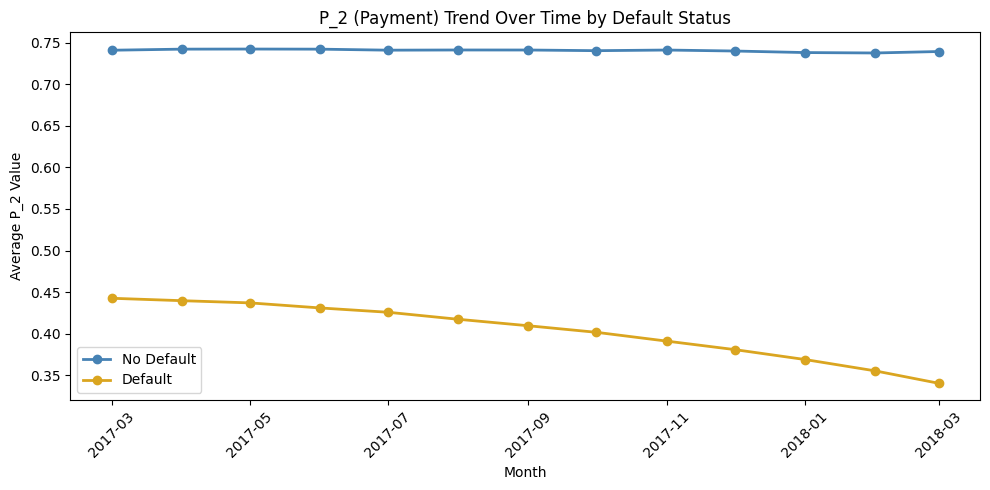

In [ ]:
monthly_trend = train_df.groupby(['year', 'month'])['P_2'].mean().reset_index()
monthly_trend['date'] = pd.to_datetime(monthly_trend[['year', 'month']].assign(day=1))

fig, ax = plt.subplots(figsize=(10, 5))

for target_val, color, label in zip([0, 1], ['steelblue', '#DAA520'], ['No Default', 'Default']):
    subset = train_df[train_df['target'] == target_val].groupby(['year', 'month'])['P_2'].mean().reset_index()
    subset['date'] = pd.to_datetime(subset[['year', 'month']].assign(day=1))
    ax.plot(subset['date'], subset['P_2'], marker='o', color=color, label=label, linewidth=2)

ax.set_xlabel('Month')
ax.set_ylabel('Average P_2 Value')
ax.set_title('P_2 (Payment) Trend Over Time by Default Status')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Customers who didn't default stay relatively steady the whole time: the line drifts only slightly from about 0.74 to 0.72 between March 2017 and March 2018. Customers who defaulted are different from the start, already around 0.44, and then they keep dropping month after month until they hit about 0.35 by the end. So it's not just a fixed gap between the two groups, there's real deterioration happening over time, which means P_2 could actually work as an early warning signal before default even happens.


## Step 18: Save the Cleaned Train/Test Sets

We now save `train_df` and `test_df` separately (rather than one combined "clean"
file) since they've already been through leakage-free, train-derived preprocessing.

In [ ]:
train_df.to_parquet('/content/amex_train.parquet', index=False)
test_df.to_parquet('/content/amex_test.parquet', index=False)
print("Saved train/test parquet files to /content/")

Saved train/test parquet files to /content/


## Step 19: Aggregate Each Customer's ~13 Monthly Rows Into One Row
Same aggregation approach as before. train_df/test_df are already sorted chronologically (Step 12), so 'last' correctly reflects each customer's most recent statement; we re-sort defensively in case cell execution order ever changes.

The old cell that separately .cat.codes-encoded D_64 on train_df/test_df before aggregation has been removed. It produced inconsistent codes between train and test and corrupted the categorical values ahead of this step's proper encoding. D_63/D_64 now stay as strings all the way through until they're encoded below, fit on train categories only.

In [ ]:
# 1. Defensive re-sort (data is already sorted from Step 12, but this keeps the cell safe
#    to run standalone / out of order).
train_df = train_df.sort_values(['customer_ID', 'S_2'])
test_df  = test_df.sort_values(['customer_ID', 'S_2'])

# 2. Split columns by type
exclude_cols = ['customer_ID', 'S_2', 'target', 'year', 'month']
categorical_cols = ['D_63', 'D_64']
numeric_cols = [c for c in train_df.columns if c not in exclude_cols + categorical_cols]

agg_funcs = ['mean', 'std', 'min', 'max', 'last']

def aggregate_customers(df):
    grouped = df.groupby('customer_ID')

    numeric_agg = grouped[numeric_cols].agg(agg_funcs)
    numeric_agg.columns = [f'{col}_{stat}' for col, stat in numeric_agg.columns]

    # Customers with only 1 statement have no std -> NaN, not missing data. Fill with 0.
    std_cols = [c for c in numeric_agg.columns if c.endswith('_std')]
    numeric_agg[std_cols] = numeric_agg[std_cols].fillna(0)

    # Categorical: most recent value
    categorical_agg = grouped[categorical_cols].agg(
        lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[-1]
    )

    target_agg = grouped['target'].first()  # identical across a customer's rows

    return pd.concat([numeric_agg, categorical_agg, target_agg], axis=1).reset_index()

train_agg = aggregate_customers(train_df)
test_agg = aggregate_customers(test_df)

# 3. Encode categoricals AFTER aggregation, fit on train only, applied to both
for col in categorical_cols:
    cats = train_agg[col].astype('category').cat.categories
    train_agg[col] = pd.Categorical(train_agg[col], categories=cats).codes
    test_agg[col]  = pd.Categorical(test_agg[col], categories=cats).codes  # unseen -> -1

# 4. Sanity checks: these should never fail if the aggregation is correct
assert train_agg['customer_ID'].is_unique and test_agg['customer_ID'].is_unique
assert train_agg.isnull().sum().sum() == 0 and test_agg.isnull().sum().sum() == 0
# Note: XGBoost/LightGBM tolerate NaN natively, so this check isn't strictly required
# for tree models, but it's kept as a general data-quality guarantee for every model.
assert not (set(train_agg['customer_ID']) & set(test_agg['customer_ID']))

print("Train:", train_agg.shape, "| Test:", test_agg.shape)

Train: (33185, 1804) | Test: (8297, 1804)


In [ ]:
train_agg.to_parquet('/content/amex_agg_train.parquet', index=False)
test_agg.to_parquet('/content/amex_agg_test.parquet', index=False)
print("Saved aggregate train/test parquet files.")

Saved aggregate train/test parquet files.


## Step 20: Build a Feature Reference Dictionary

One reference table, one row per **original** (pre-aggregation) feature, that records
every decision this notebook made about it: category, original missing %, dropped or
kept, correlation with `target`, outlier-capping bounds, fill strategy, and which
aggregation stats it feeds into. We save it to disk so the modelling notebooks
(Logistic Regression, XGBoost, LightGBM, LSTM), and anyone reviewing them, can
look a column up by name instead of re-deriving "why does this feature look like this"
from memory or re-reading this whole notebook.


In [ ]:
data_dict = pd.DataFrame({'feature': df.columns})

data_dict['category'] = data_dict['feature'].apply(get_category)
data_dict['dtype_original'] = data_dict['feature'].map(df.dtypes.astype(str))
data_dict['missing_pct_original'] = data_dict['feature'].map(missing_pct).fillna(0.0)
data_dict['dropped_high_missing'] = data_dict['feature'].isin(columns_to_drop)
data_dict['corr_with_target'] = data_dict['feature'].map(correlations).round(4)

def _fill_method(col):
    if col in columns_to_drop or col in ['customer_ID', 'S_2', 'target']:
        return 'N/A'
    if col in numeric_cols_missing or col in categorical_cols_missing:
        return 'per-customer ffill/bfill -> train median/mode fallback'
    return 'no missing values found'

data_dict['fill_method'] = data_dict['feature'].apply(_fill_method)

data_dict['capped_1_99pct'] = data_dict['feature'].isin(cap_bounds.keys())
data_dict['cap_lower'] = data_dict['feature'].map(lambda c: cap_bounds.get(c, (np.nan, np.nan))[0])
data_dict['cap_upper'] = data_dict['feature'].map(lambda c: cap_bounds.get(c, (np.nan, np.nan))[1])

data_dict['agg_stats_used'] = data_dict['feature'].apply(
    lambda c: ', '.join(agg_funcs) if c in numeric_cols
    else ('mode (most frequent), encoded post-aggregation' if c in categorical_cols
          else 'N/A, dropped before aggregation')
)

# Append rows for engineered (non-original) features created earlier in the notebook
# (missing-indicator flags, n_statements, log1p transforms), so the dictionary stays a
# complete reference once those steps have run.
engineered_rows = []

for col in missing_flag_cols:
    orig = col.replace('_was_missing', '')
    engineered_rows.append({
        'feature': col, 'category': 'Engineered (missing flag)',
        'dtype_original': 'int (0/1)', 'missing_pct_original': 0.0,
        'dropped_high_missing': False, 'corr_with_target': np.nan,
        'fill_method': 'N/A, derived, no missing itself',
        'capped_1_99pct': False, 'cap_lower': np.nan, 'cap_upper': np.nan,
        'agg_stats_used': ', '.join(agg_funcs) + f' (fraction of months {orig} was missing)'
    })

engineered_rows.append({
    'feature': 'n_statements', 'category': 'Engineered (customer history length)',
    'dtype_original': 'int', 'missing_pct_original': 0.0, 'dropped_high_missing': False,
    'corr_with_target': np.nan, 'fill_method': 'N/A, derived from row counts',
    'capped_1_99pct': False, 'cap_lower': np.nan, 'cap_upper': np.nan,
    'agg_stats_used': ', '.join(agg_funcs) + ' (constant per customer, stats collapse to one value)'
})

for col in log_transform_cols:
    engineered_rows.append({
        'feature': f'{col}_log', 'category': 'Engineered (log1p transform)',
        'dtype_original': 'float', 'missing_pct_original': 0.0, 'dropped_high_missing': False,
        'corr_with_target': np.nan, 'fill_method': 'N/A, derived from the already-capped column',
        'capped_1_99pct': True, 'cap_lower': np.nan, 'cap_upper': np.nan,
        'agg_stats_used': ', '.join(agg_funcs) + f' (log1p of {col}, for Logistic Regression only)'
    })

if engineered_rows:
    data_dict = pd.concat([data_dict, pd.DataFrame(engineered_rows)], ignore_index=True)

data_dict = data_dict.sort_values(
    ['dropped_high_missing', 'category', 'feature']
).reset_index(drop=True)

data_dict.to_csv('/content/firasa_feature_dictionary.csv', index=False)

print(f"Feature dictionary built: {data_dict.shape[0]} rows x {data_dict.shape[1]} columns")
print("Saved to /content/firasa_feature_dictionary.csv")
data_dict.head(15)

Feature dictionary built: 396 rows x 11 columns
Saved to /content/ferasa_feature_dictionary.csv


,feature,category,dtype_original,missing_pct_original,dropped_high_missing,corr_with_target,fill_method,capped_1_99pct,cap_lower,cap_upper,agg_stats_used
0,B_1,Balance,float32,0.00,False,0.3864,no missing values found,True,0.000488,1.010405,"mean, std, min, max, last"
1,B_10,Balance,float32,0.00,False,-0.0174,no missing values found,True,0.004601,1.032613,"mean, std, min, max, last"
2,B_11,Balance,float32,0.00,False,0.3653,no missing values found,True,0.000321,1.013499,"mean, std, min, max, last"
3,B_12,Balance,float32,0.00,False,-0.0488,no missing values found,True,0.002579,1.011007,"mean, std, min, max, last"
4,B_13,Balance,float32,0.88,False,-0.0436,per-customer ffill/bfill -> train median/mode ...,True,0.000583,1.016916,"mean, std, min, max, last"
5,B_14,Balance,float32,0.00,False,0.0816,no missing values found,True,0.000364,1.006269,"mean, std, min, max, last"
6,B_15,Balance,float32,0.14,False,0.0058,per-customer ffill/bfill -> train median/mode ...,True,0.000116,1.012475,"mean, std, min, max, last"
7,B_16,Balance,float32,0.03,False,0.3945,per-customer ffill/bfill -> train median/mode ...,True,0.000253,1.009455,"mean, std, min, max, last"
8,B_18,Balance,float32,0.00,False,-0.4852,no missing values found,True,0.003759,1.009736,"mean, std, min, max, last"
9,B_19,Balance,float32,0.03,False,0.3919,per-customer ffill/bfill -> train median/mode ...,True,0.000136,1.007666,"mean, std, min, max, last"


**Insight:**
The dictionary has one row per one of the 192 original columns.

- **Dropped columns are documented too:** the 31 that got dropped (`dropped_high_missing` = True, everything else N/A) still have a record explaining why they disappeared before aggregation.
- **For every kept feature**, one lookup answers:
  - Which category it belongs to
  - How much of it was originally missing
  - How it was filled
  - Its train-only outlier-capping bounds
  - Its correlation with target
  - Which aggregation stats (mean/std/min/max/last) carried it into amex_agg_train.parquet

This is the table to pull up whenever a modelling notebook needs to explain a feature's behavior, instead of re-reading this whole notebook.


## Notebook Summary of Firasa EDA (Exploring Early Warning Signals)

### Dataset Scale
- ~458,913 unique customers in the full Amex dataset
- Sampled 41,482 of them (customer-level sampling, so no customer's monthly history was cut off)
- Final sample: **501,032 rows x 192 columns**, averaging ~12.05 statements per customer

### Column Cleanup
- Categorized columns by type, mostly Delinquency indicators, followed by Balance, Risk, and Spend
- Dropped 30 columns that were nearly empty (>50% missing) plus a leftover pandas index artifact, down to **161 columns**, no rows lost

### Target Variable
- Clearly imbalanced: **75.5% "no default" vs. 24.5% "default"**
- This is why ROC-AUC (not accuracy) and class_weight/scale_pos_weight are used in the modelling notebooks

### Correlation & Feature Behavior
- Strongest features tied to target: **P_2** (negative), **D_48**, **D_61**, **B_18** (positive)
- Boxplots and KDE distributions confirmed clear separation between the two classes across all four
- Quantified multicollinearity with VIF and a |corr| > 0.9 pairwise table (Step 10.1) instead of only describing it qualitatively

### Time-Based Signal
- Tracked P_2 over time: gradually declines for defaulting customers month over month leading up to default, while staying roughly flat for non-defaulters
- Suggests P_2 could work as a genuine early-warning signal, not just a fixed gap between groups

### Engineered Features (New This Pass)
- **Missing-indicator flags** (`{col}_was_missing`, 92 columns) and a per-customer **n_statements** feature, captured before the fill, so genuine missingness patterns aren't lost (Step 13a)
- **Train/test comparison**: documented that default rate, feature stats, and calendar-month distribution line up closely between the two sets (Step 14.1 to 14.2)
- **Post-capping skewness check**: 113 of 157 numeric columns still heavily skewed after outlier capping; created log1p versions for 111 of them (2 skipped, they contain negative values), kept alongside the originals for the Logistic Regression pipeline specifically (Step 16.1)

### Outputs Saved (For Modeling Phase)
- **amex_train.parquet / amex_test.parquet** (Step 18): leakage-free, one row per customer per month. This is the version an LSTM or GRU should train on, since it needs the raw time sequence.
- **amex_agg_train.parquet / amex_agg_test.parquet** (Step 19): one row per customer via mean/std/min/max/last. Final shape: **train (33,185 x 1,804), test (8,297 x 1,804)**. This is the version Logistic Regression, XGBoost, and LightGBM should train on, since tree/linear models need the time dimension flattened first.
- **firasa_feature_dictionary.csv** (Step 20): one row per original column (392 + engineered = **396 rows**), documenting category, missing %, drop/keep status, correlation with target, capping bounds, and fill strategy, the lookup table for any modelling notebook that needs to explain a feature's behavior without re-reading this whole notebook.
